In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

housing = pd.read_csv('housing.csv')

housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [48]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [49]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


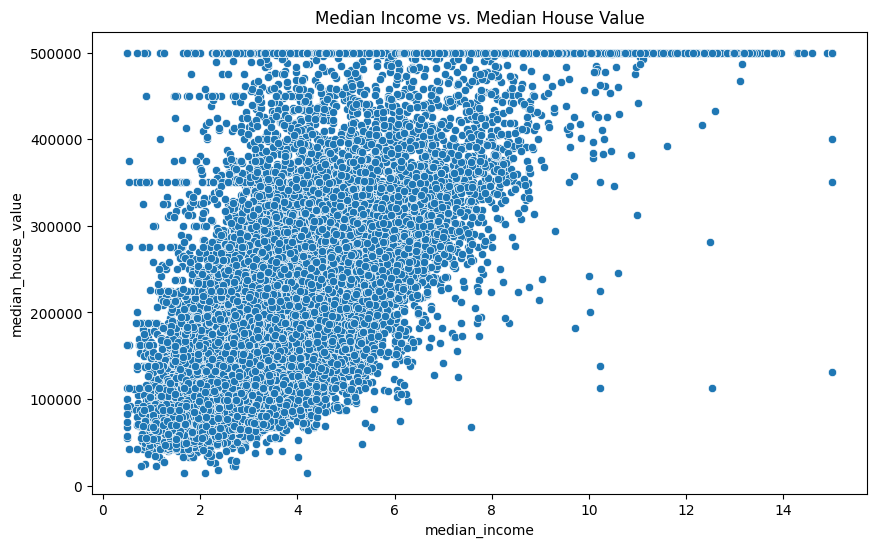

In [50]:
# Create a scatter plot of median_income vs. median_house_value
plt.figure(figsize=(10,6))
sns.scatterplot(data=housing, x='median_income', y='median_house_value')
plt.title('Median Income vs. Median House Value')
plt.show()

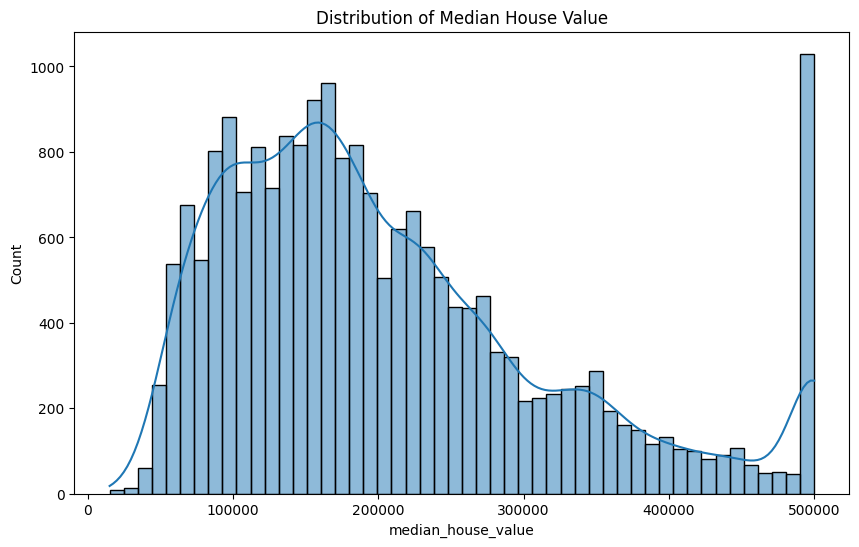

In [51]:
# Create a histogram of median_house_value
plt.figure(figsize=(10,6))
sns.histplot(housing['median_house_value'], bins=50, kde=True)
plt.title('Distribution of Median House Value')
plt.show()

In [52]:
# Check for missing values
housing.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


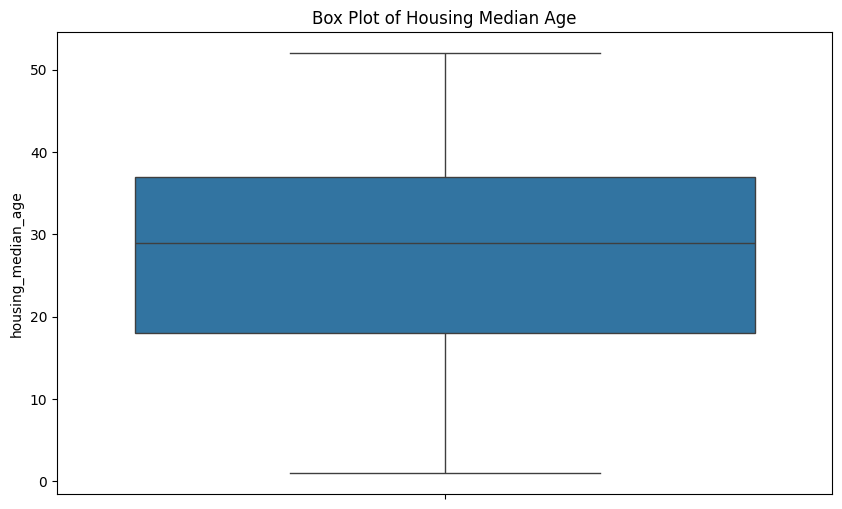

In [53]:
# Create box plots to detect outliers
plt.figure(figsize=(10,6))
sns.boxplot(data=housing['housing_median_age'])
plt.title('Box Plot of Housing Median Age')
plt.show()

/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


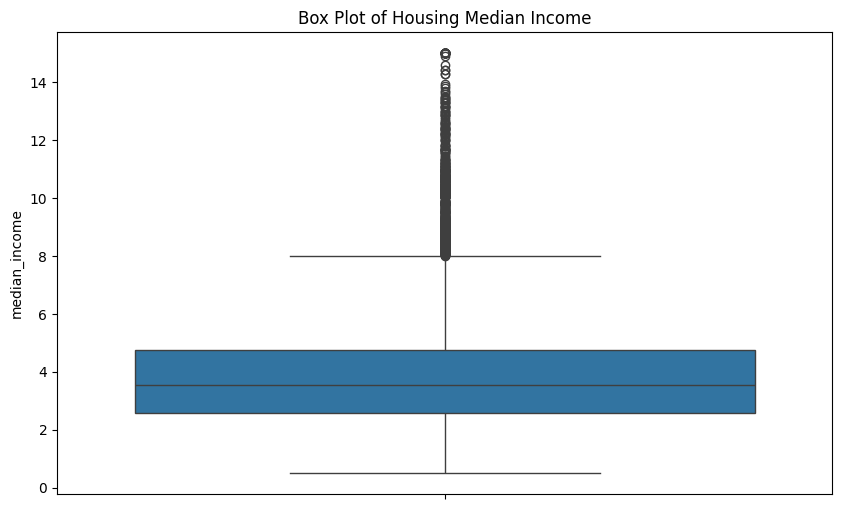

In [54]:
plt.figure(figsize=(10,6))
sns.boxplot(data=housing['median_income'])
plt.title('Box Plot of Housing Median Income')
plt.show()

/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


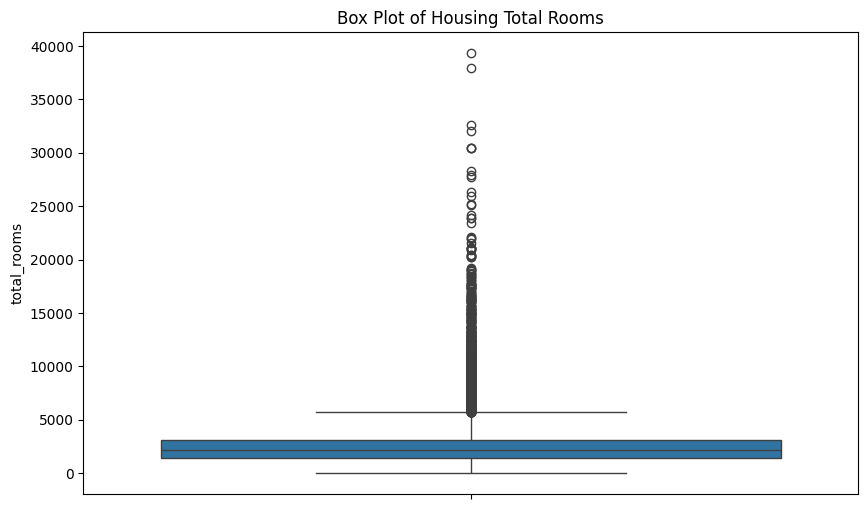

In [55]:
plt.figure(figsize=(10,6))
sns.boxplot(data=housing['total_rooms'])
plt.title('Box Plot of Housing Total Rooms')
plt.show()

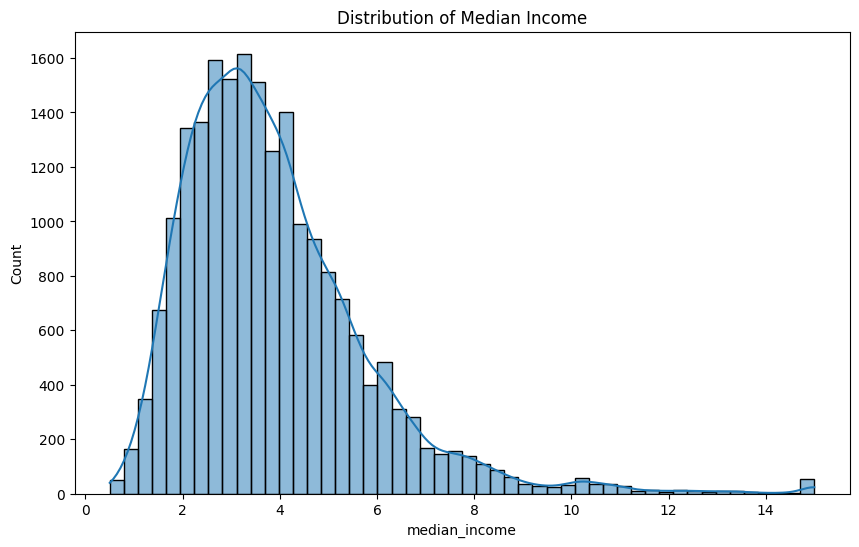

In [56]:
# Distribution of median_income
plt.figure(figsize=(10,6))
sns.histplot(housing['median_income'], bins=50, kde=True)
plt.title('Distribution of Median Income')
plt.show()

In [57]:
# Calculate skewness
skewness = housing['median_income'].skew()
print(f'Skewness: {skewness}')

Skewness: 1.6466567021344465


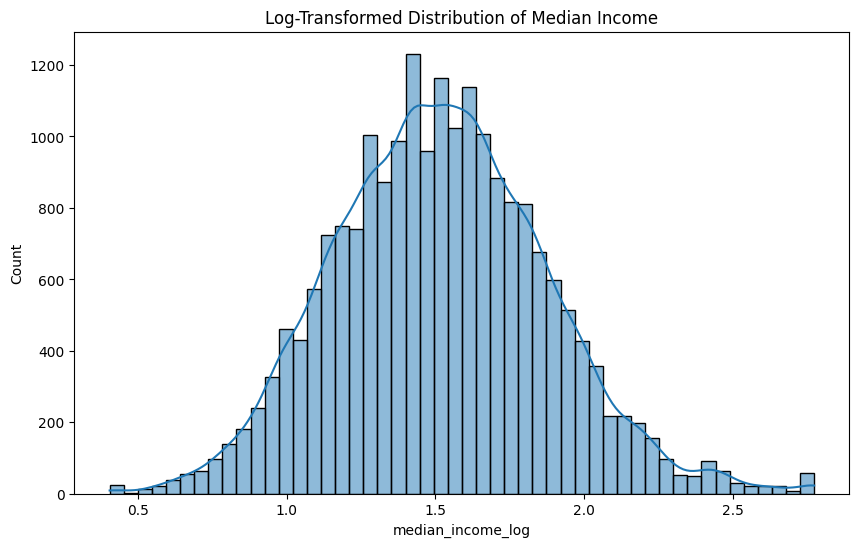

In [58]:
housing['median_income_log'] = np.log(housing['median_income'] + 1)

plt.figure(figsize=(10, 6))
sns.histplot(housing['median_income_log'], bins=50, kde=True)
plt.title('Log-Transformed Distribution of Median Income')
plt.show()

In [59]:
# Calculate skewness after transformation
skewness_log = housing['median_income_log'].skew()
print(f'Skewness after log transformation: {skewness_log}')

Skewness after log transformation: 0.22608313067130548


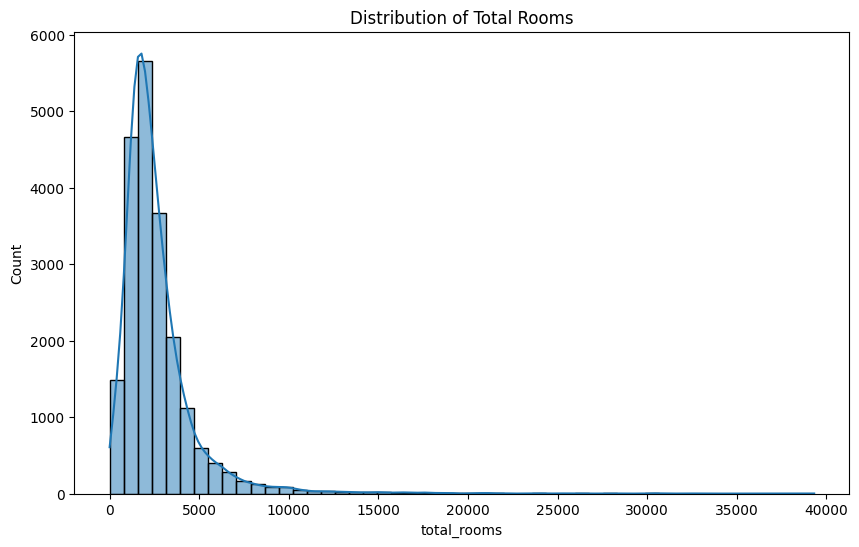

In [60]:
# Distribution of total_rooms
plt.figure(figsize=(10,6))
sns.histplot(housing['total_rooms'], bins=50, kde=True)
plt.title('Distribution of Total Rooms')
plt.show()

In [61]:
# Calculate skewness
skewness = housing['total_rooms'].skew()
print(f'Skewness: {skewness}')

Skewness: 4.147343450632158


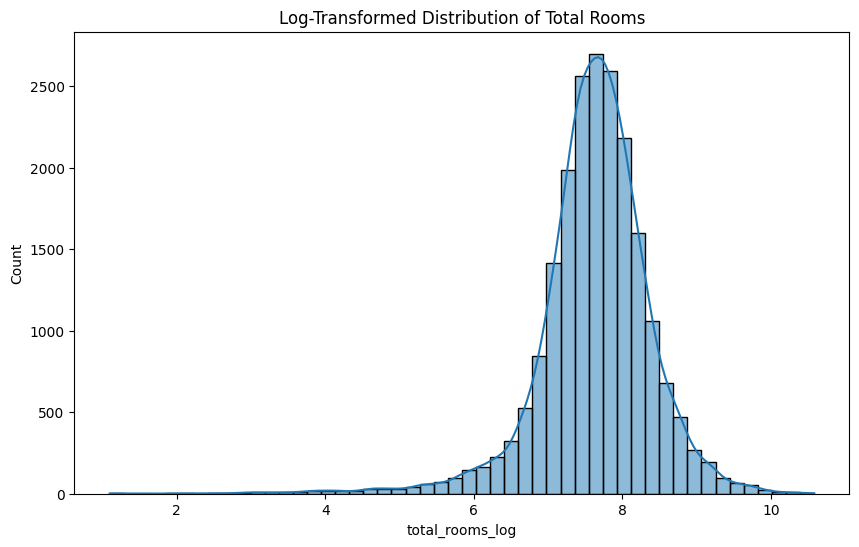

In [62]:
housing['total_rooms_log'] = np.log(housing['total_rooms'] + 1)

plt.figure(figsize=(10, 6))
sns.histplot(housing['total_rooms_log'], bins=50, kde=True)
plt.title('Log-Transformed Distribution of Total Rooms')
plt.show()

In [63]:
# Calculate skewness after transformation
skewness_log = housing['total_rooms_log'].skew()
print(f'Skewness after log transformation: {skewness_log}')

Skewness after log transformation: -1.0755326843333637


In [64]:
# Display unique values in ocean_proximity
housing['ocean_proximity'].unique()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

In [65]:
# Perform One-Hot Encoding on ocean_proximity
housing_encoded = pd.get_dummies(housing, columns=['ocean_proximity'])
housing_encoded.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,median_income_log,total_rooms_log,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,2.232720,6.781058,False,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,2.230165,8.867850,False,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,2.111110,7.291656,False,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,1.893579,7.150701,False,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,1.578195,7.395108,False,False,False,True,False


In [68]:
# Define features and target variable
features = ['median_income', 'housing_median_age', 'total_rooms'] + list(housing_encoded.columns[-5:])
X = housing_encoded[features]
y = housing_encoded['median_house_value']

# Split the dataset (70% training, 30% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [69]:
# Create the model instance
model = LinearRegression()

# Fit the model to the training data
model.fit(X_train, y_train)

LinearRegression()

In [70]:
# Predict on the test set
y_pred = model.predict(X_test)

# Import metrics


# Calculate R² score
r2 = r2_score(y_test, y_pred)
print(f'R² Score: {r2}')

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'RMSE: {rmse}')

R² Score: 0.5984117540230909
RMSE: 72601.69968198489


In [71]:
# Predict on the training set
y_train_pred = model.predict(X_train)

# Calculate R² score for training set
r2_train = r2_score(y_train, y_train_pred)
print(f'Training R² Score: {r2_train}')

# Calculate RMSE for training set
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
print(f'Training RMSE: {rmse_train}')

Training R² Score: 0.6013200222579779
Training RMSE: 73082.82715382468


In [72]:
# Create a dataframe of features and their coefficients
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_
})

# Display the coefficients
coefficients.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
5,ocean_proximity_ISLAND,144246.065202
0,median_income,37542.247005
1,housing_median_age,1156.614271
2,total_rooms,3.746631
7,ocean_proximity_NEAR OCEAN,-8461.870682
6,ocean_proximity_NEAR BAY,-13863.962313
3,ocean_proximity_<1H OCEAN,-24695.571036
4,ocean_proximity_INLAND,-97224.661172


In [73]:
# Compute the correlation matrix
corr_matrix = housing_encoded.corr()

# Display the correlation with median_house_value
corr_matrix['median_house_value'].sort_values(ascending=False)

,median_house_value
median_house_value,1.000000
median_income,0.688075
median_income_log,0.669914
ocean_proximity_<1H OCEAN,0.256617
ocean_proximity_NEAR BAY,0.160284
total_rooms_log,0.159422
ocean_proximity_NEAR OCEAN,0.141862
total_rooms,0.134153
housing_median_age,0.105623
households,0.065843
